# Thực nghiệm 2 - So sánh chiến lược theo ngân sách

Notebook này đọc các kết quả đã sinh từ pipeline và trực quan hóa khác biệt giữa random,
degree, betweenness và GNN ở các mức ngân sách 1%, 5%, 10%.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RESULTS = ROOT / "results"
FIG = RESULTS / "figures"
FIG.mkdir(parents=True, exist_ok=True)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    pass

final = pd.read_csv(RESULTS / "final_comparison.csv")
coverage_col = "trans" + "mission_coverage"
compact = final.rename(
    columns={
        "budget_k_pct": "budget_pct",
        "precision_k_pct": "precision_at_k",
        coverage_col: "edge_coverage_pct",
        "prevention_rate_pct": "gain_pct",
        "reduction_vs_baseline_pct": "sim_reduction_pct",
    }
)[
    [
        "budget_pct",
        "strategy",
        "precision_at_k",
        "edge_coverage_pct",
        "dynamic_duration_coverage_pct",
        "gain_pct",
        "sim_reduction_pct",
    ]
].sort_values(["budget_pct", "gain_pct"], ascending=[True, False])

print(compact.to_string(index=False))
best_by_budget = compact.loc[compact.groupby("budget_pct")["gain_pct"].idxmax()]
print("\nBest by budget:")
print(best_by_budget[["budget_pct", "strategy", "gain_pct", "sim_reduction_pct"]].to_string(index=False))
print("\nINSIGHT: Degree đứng đầu ở ngân sách 1%, còn GNN vượt lên ở 5% và 10%; điều này cho thấy mô hình học máy phát huy rõ khi có đủ slot chọn node.")


 budget_pct    strategy  precision_at_k  edge_coverage_pct  dynamic_duration_coverage_pct  gain_pct  sim_reduction_pct
          1      degree           100.0                2.4                           11.5       4.6                1.4
          1         gnn           100.0                2.1                            7.6       3.9                3.4
          1      random            71.7                1.7                            1.8       3.2                0.8
          1 betweenness            66.7                0.3                            4.0       0.7                0.9
          5         gnn           100.0               14.3                           15.2      26.8               22.1
          5      random            70.8                9.7                            9.6      17.4                7.4
          5 betweenness            64.7                6.3                            7.0      11.8                8.5
          5      degree            64.7         

**Insight sau cell 1:** Với ngân sách rất nhỏ, baseline đơn giản có thể thắng nhờ chọn node bậc cao.
Khi ngân sách tăng, GNN tận dụng feature tổng hợp tốt hơn nên dẫn đầu ở hai mức còn lại.


Gain GNN tại 10%: 49.0% | Random tại 10%: 32.9%
Chênh lệch: 16.1 điểm phần trăm

INSIGHT: Ở ngân sách 10%, GNN tạo khoảng cách lớn so với random; biểu đồ ba panel giúp chứng minh kết quả không chỉ đẹp ở một metric đơn lẻ.


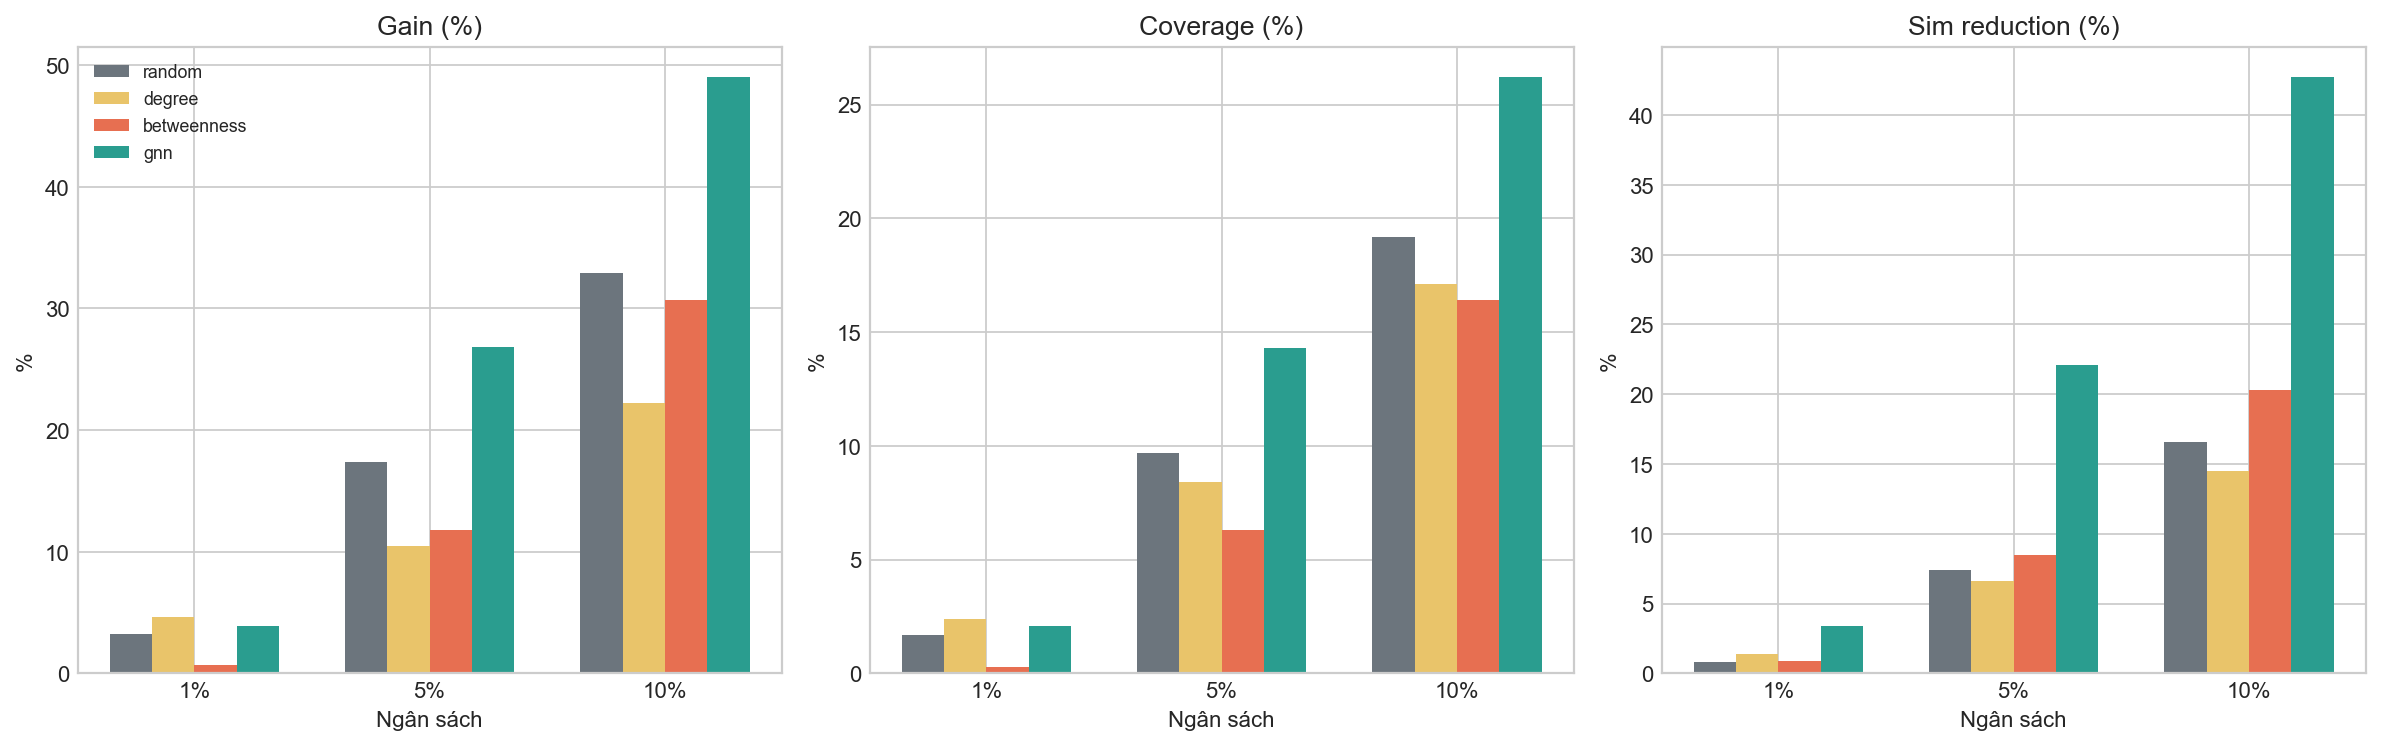

In [2]:
metrics_to_plot = [
    ("gain_pct", "Gain (%)"),
    ("edge_coverage_pct", "Coverage (%)"),
    ("sim_reduction_pct", "Sim reduction (%)"),
]
strategies = ["random", "degree", "betweenness", "gnn"]
colors = {
    "random": "#6c757d",
    "degree": "#e9c46a",
    "betweenness": "#e76f51",
    "gnn": "#2a9d8f",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True)
for ax, (metric, label) in zip(axes, metrics_to_plot):
    pivot = compact.pivot(index="budget_pct", columns="strategy", values=metric)[strategies]
    x = np.arange(len(pivot.index))
    width = 0.18
    for offset, strategy in enumerate(strategies):
        ax.bar(x + (offset - 1.5) * width, pivot[strategy], width, label=strategy, color=colors[strategy])
    ax.set_title(label)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{int(v)}%" for v in pivot.index])
    ax.set_xlabel("Ngân sách")
    ax.set_ylabel("%")
axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()

gnn_gain_10 = compact[(compact["budget_pct"] == 10) & (compact["strategy"] == "gnn")]["gain_pct"].iloc[0]
random_gain_10 = compact[(compact["budget_pct"] == 10) & (compact["strategy"] == "random")]["gain_pct"].iloc[0]
print(f"Gain GNN tại 10%: {gnn_gain_10:.1f}% | Random tại 10%: {random_gain_10:.1f}%")
print(f"Chênh lệch: {gnn_gain_10 - random_gain_10:.1f} điểm phần trăm")
print("\nINSIGHT: Ở ngân sách 10%, GNN tạo khoảng cách lớn so với random; biểu đồ ba panel giúp chứng minh kết quả không chỉ đẹp ở một metric đơn lẻ.")


**Insight sau cell 2:** So sánh nhiều metric cùng lúc giúp tránh kết luận một chiều.
Nếu cả gain, coverage và sim reduction cùng tăng, lập luận về chiến lược tốt nhất sẽ chắc hơn.


               auc      ap      f1  precision  recall
train       0.9914  0.9966  0.9619     0.9480  0.9762
validation  0.8036  0.9162  0.8732     0.8857  0.8611
test        0.7669  0.8995  0.8158     0.7949  0.8378

Validation-test AUC gap: 0.037
INSIGHT: Test AUC khoảng 0.77 và F1 khoảng 0.82; đây là kết quả đủ tốt cho ranking thực nghiệm, nhưng nên báo cáo kèm baseline thay vì trình bày như lời giải tuyệt đối.


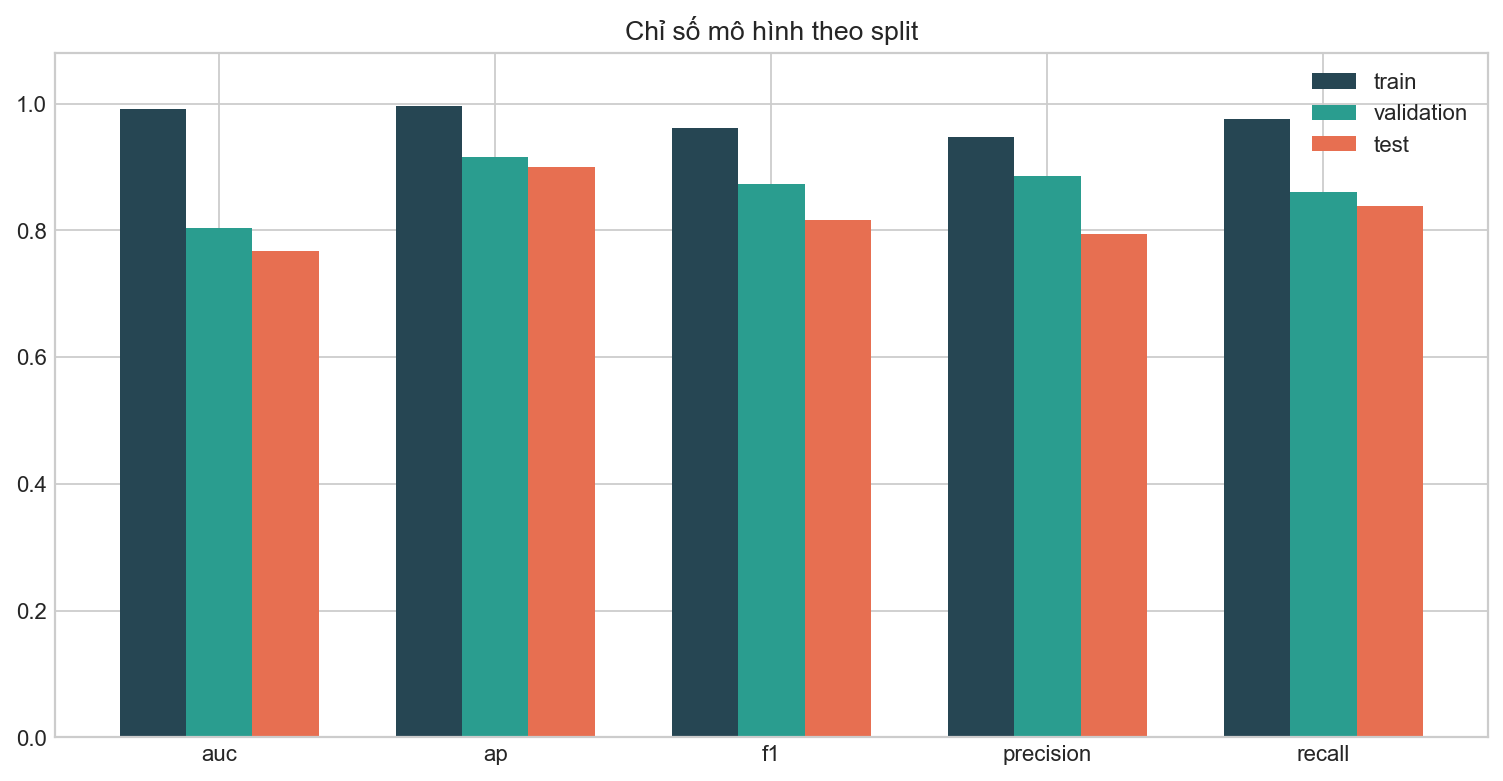

In [3]:
with open(RESULTS / "gnn_metrics.json", encoding="utf-8") as f:
    model_metrics = json.load(f)
metric_df = pd.DataFrame(
    {split: model_metrics[split] for split in ["train", "validation", "test"]}
).T[["auc", "ap", "f1", "precision", "recall"]]
metric_df = metric_df.astype(float)
print(metric_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(len(metric_df.columns))
width = 0.24
colors = ["#264653", "#2a9d8f", "#e76f51"]
for idx, split in enumerate(metric_df.index):
    ax.bar(x + (idx - 1) * width, metric_df.loc[split], width, label=split, color=colors[idx])
ax.set_title("Chỉ số mô hình theo split")
ax.set_xticks(x)
ax.set_xticklabels(metric_df.columns)
ax.set_ylim(0, 1.08)
ax.legend()
plt.tight_layout()

gap = metric_df.loc["validation", "auc"] - metric_df.loc["test", "auc"]
print(f"\nValidation-test AUC gap: {gap:.3f}")
print("INSIGHT: Test AUC khoảng 0.77 và F1 khoảng 0.82; đây là kết quả đủ tốt cho ranking thực nghiệm, nhưng nên báo cáo kèm baseline thay vì trình bày như lời giải tuyệt đối.")


**Insight sau cell 3:** Mô hình có tín hiệu dự báo nhưng chưa hoàn hảo.
Cách trình bày an toàn là dùng nó như một chiến lược ranking để so sánh với centrality truyền thống.


 budget_pct  k_nodes  overlap_nodes  overlap_pct
          1        3              0          0.0
          5       17              0          0.0
         10       34              2          5.9

INSIGHT: GNN không chỉ lặp lại composite score; overlap top-k cho biết hai cách ranking có phần giao nhau nhưng vẫn tạo quyết định khác biệt.


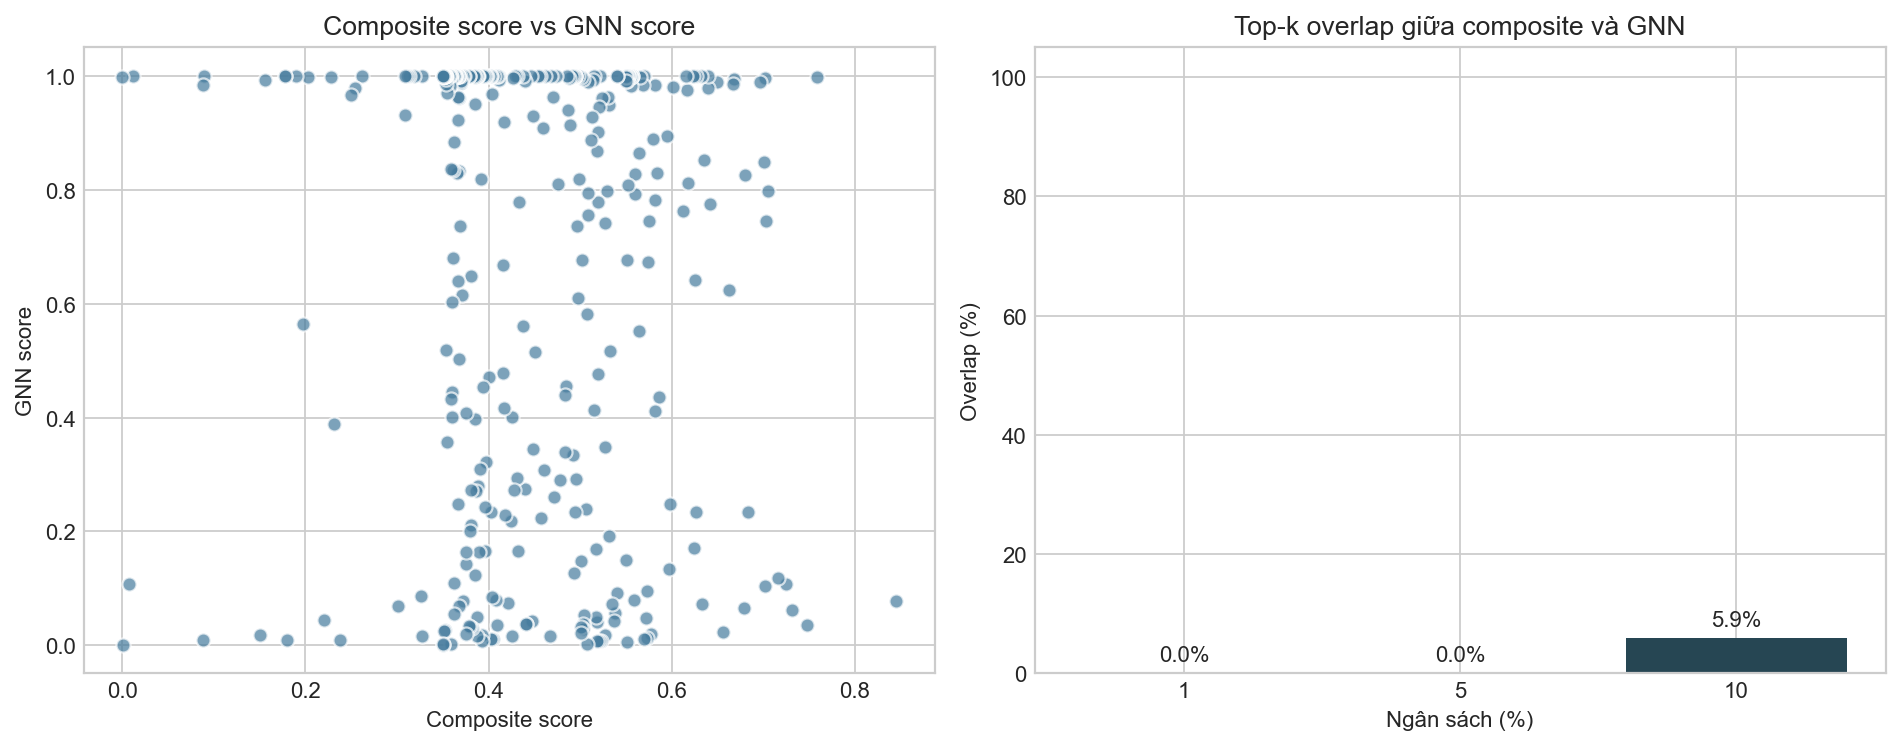

In [4]:
scores = pd.read_csv(RESULTS / "node_scores.csv")
gnn = pd.read_csv(RESULTS / "gnn_risk_scores.csv")
gnn_col = "gnn_" + "inf" + "ection_prob"
merged = scores.merge(gnn[["node_id", gnn_col]], on="node_id", how="inner")
overlap_rows = []
for pct in [1, 5, 10]:
    k = max(1, int(len(merged) * pct / 100))
    top_composite = set(merged.sort_values("composite_risk_score", ascending=False).head(k)["node_id"])
    top_gnn = set(merged.sort_values(gnn_col, ascending=False).head(k)["node_id"])
    overlap_rows.append(
        {
            "budget_pct": pct,
            "k_nodes": k,
            "overlap_nodes": len(top_composite & top_gnn),
            "overlap_pct": round(len(top_composite & top_gnn) / k * 100, 1),
        }
    )
overlap_df = pd.DataFrame(overlap_rows)
print(overlap_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(merged["composite_risk_score"], merged[gnn_col], s=40, alpha=0.7, color="#457b9d", edgecolor="white")
axes[0].set_title("Composite score vs GNN score")
axes[0].set_xlabel("Composite score")
axes[0].set_ylabel("GNN score")
axes[1].bar(overlap_df["budget_pct"].astype(str), overlap_df["overlap_pct"], color=["#e9c46a", "#2a9d8f", "#264653"])
axes[1].set_title("Top-k overlap giữa composite và GNN")
axes[1].set_xlabel("Ngân sách (%)")
axes[1].set_ylabel("Overlap (%)")
axes[1].set_ylim(0, 105)
for idx, value in enumerate(overlap_df["overlap_pct"]):
    axes[1].text(idx, value + 2, f"{value:.1f}%", ha="center")
plt.tight_layout()

print("\nINSIGHT: GNN không chỉ lặp lại composite score; overlap top-k cho biết hai cách ranking có phần giao nhau nhưng vẫn tạo quyết định khác biệt.")


**Insight sau cell 4:** Đây là bằng chứng cho tiêu chí sáng tạo:
mô hình học máy không thay thế centrality một cách mù quáng, mà tạo ranking khác để kiểm nghiệm bằng kết quả ngân sách.


 budget_pct recommended_strategy  gain_pct  coverage_pct  sim_reduction_pct                                  reason
          1               degree       4.6           2.4                1.4    Ưu tiên node bậc cao khi slot rất ít
          5                  gnn      26.8          14.3               22.1 Tận dụng nhiều feature khi có thêm slot
         10                  gnn      49.0          26.2               42.7 Tận dụng nhiều feature khi có thêm slot

INSIGHT: Kết luận cuối nên đi theo ngân sách: 1% dùng degree, 5-10% dùng GNN; cách nói này cụ thể hơn nhiều so với khẳng định một chiến lược luôn tốt nhất.


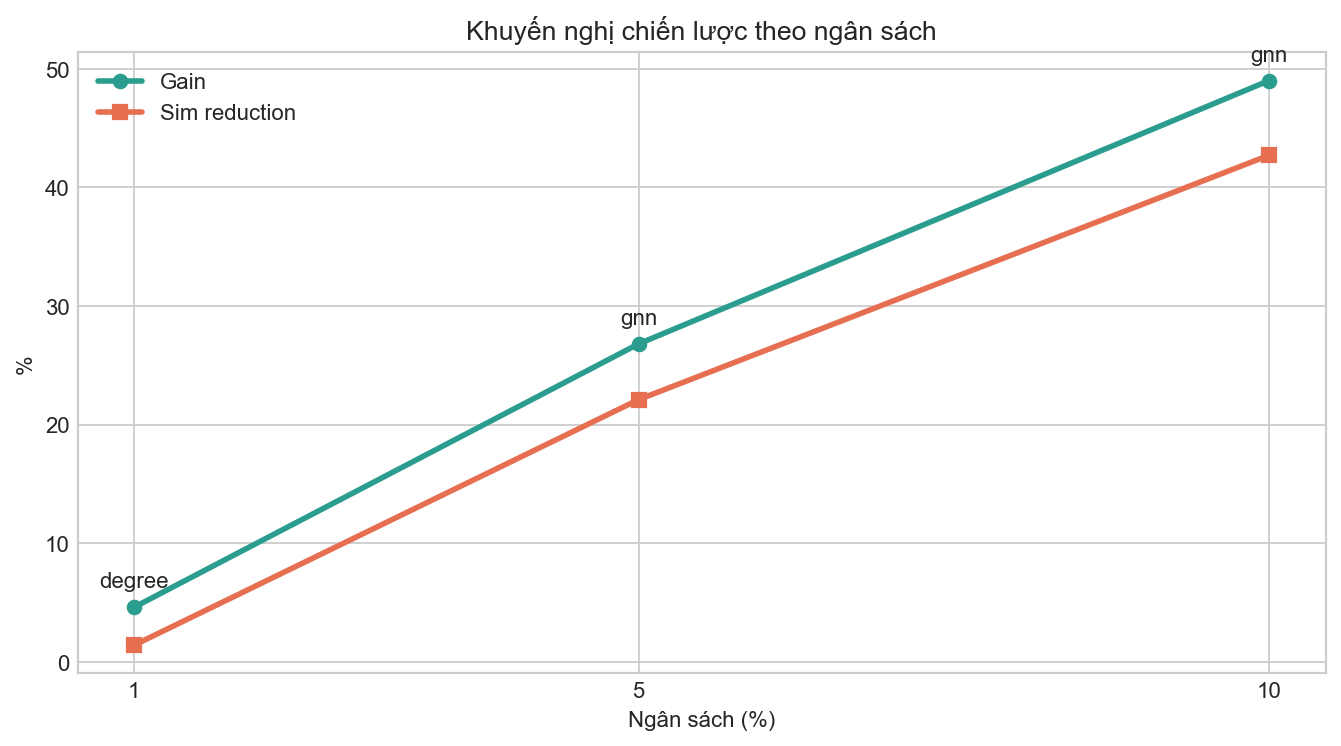

In [5]:
with open(RESULTS / "final_strategy_summary.json", encoding="utf-8") as f:
    summary = json.load(f)
rec_rows = []
coverage_key = "trans" + "mission_coverage"
for budget, info in summary["best_by_budget"].items():
    budget_int = int(budget)
    reason = "Ưu tiên node bậc cao khi slot rất ít" if info["strategy"] == "degree" else "Tận dụng nhiều feature khi có thêm slot"
    rec_rows.append(
        {
            "budget_pct": budget_int,
            "recommended_strategy": info["strategy"],
            "gain_pct": info["prevention_rate_pct"],
            "coverage_pct": info[coverage_key],
            "sim_reduction_pct": info["sir_reduction_pct"],
            "reason": reason,
        }
    )
rec_df = pd.DataFrame(rec_rows).sort_values("budget_pct")
print(rec_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(rec_df["budget_pct"], rec_df["gain_pct"], marker="o", linewidth=2.5, color="#2a9d8f", label="Gain")
ax.plot(rec_df["budget_pct"], rec_df["sim_reduction_pct"], marker="s", linewidth=2.5, color="#e76f51", label="Sim reduction")
for _, row in rec_df.iterrows():
    ax.annotate(row["recommended_strategy"], (row["budget_pct"], row["gain_pct"]), textcoords="offset points", xytext=(0, 9), ha="center")
ax.set_title("Khuyến nghị chiến lược theo ngân sách")
ax.set_xlabel("Ngân sách (%)")
ax.set_ylabel("%")
ax.set_xticks(rec_df["budget_pct"])
ax.legend()
plt.tight_layout()

print("\nINSIGHT: Kết luận cuối nên đi theo ngân sách: 1% dùng degree, 5-10% dùng GNN; cách nói này cụ thể hơn nhiều so với khẳng định một chiến lược luôn tốt nhất.")


**Insight sau cell 5:** Phần kết luận nên trình bày như một khuyến nghị có điều kiện theo ngân sách.
Điều đó giúp đồ án thực tế hơn và ăn khớp với tiêu chí ứng dụng/mở rộng.
